In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect("lakehouse.duckdb")
sns.set_style("whitegrid")

In [2]:
con.execute("SHOW TABLES").df()

,name
0,dim_cliente
1,dim_producto
2,fact_cliente
3,fact_producto
4,raw_customers
5,raw_orders
6,raw_products
7,stage_customers
8,stage_orders
9,stage_products


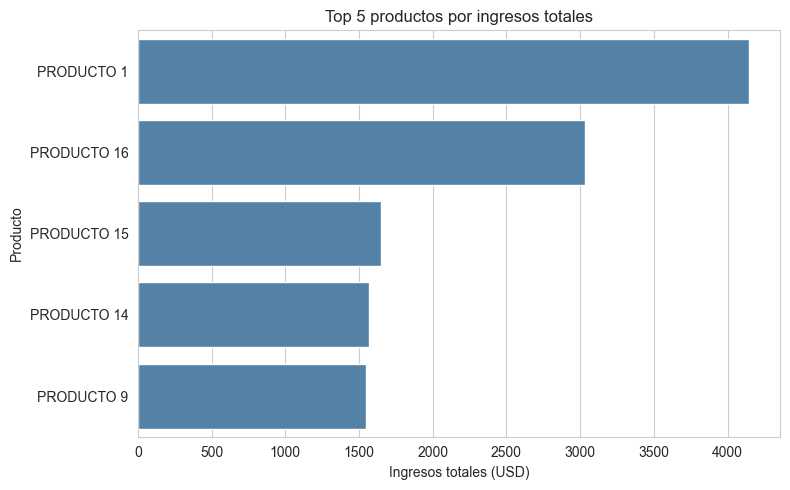

In [ ]:
# Gráfico con los 5 productos mas vendidos
df_top5 = con.execute("""
    SELECT p.product_name, f.ingresos_totales
    FROM fact_producto f
    JOIN dim_producto p ON f.product_id = p.product_id
    ORDER BY f.ingresos_totales DESC
    LIMIT 5
""").df()

plt.figure(figsize=(8,5))
sns.barplot(data=df_top5, x="ingresos_totales", y="product_name", color="steelblue")
plt.title("Top 5 productos por ingresos totales")
plt.xlabel("Ingresos totales (USD)")
plt.ylabel("Producto")
plt.tight_layout()
plt.show()

**Top 5 productos por ingresos.** Este gráfico muestra los 5 productos que generaron 
mayores ingresos totales dentro del periodo analizado. Identificar estos productos 
permite priorizar su disponibilidad en inventario y evaluar si existe una categoría 
predominante entre ellos, lo cual puede orientar decisiones de marketing o 
abastecimiento hacia los productos de mayor impacto en los ingresos del negocio.

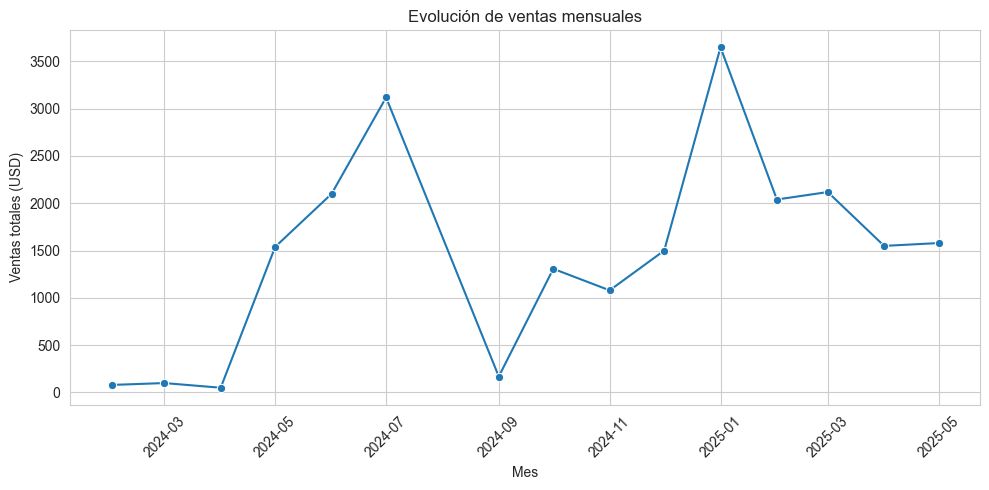

In [6]:
# Gráfico de evolución de ventas mes a mes
df_mensual = con.execute("""
    SELECT 
        DATE_TRUNC('month', order_date) AS mes,
        SUM(total_amount_usd) AS ventas_totales
    FROM stage_orders
    WHERE order_date IS NOT NULL
    GROUP BY DATE_TRUNC('month', order_date)
    ORDER BY mes
""").df()

plt.figure(figsize=(10,5))
sns.lineplot(data=df_mensual, x="mes", y="ventas_totales", marker="o")
plt.title("Evolución de ventas mensuales")
plt.xlabel("Mes")
plt.ylabel("Ventas totales (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evolución de ventas mensuales.** Este gráfico permite observar la tendencia de 
ventas a lo largo del tiempo, identificando posibles meses de mayor o menor 
actividad comercial. Detectar estos patrones estacionales es útil para anticipar 
necesidades de stock, planificar campañas en los meses de menor venta, o entender 
si el negocio está creciendo, manteniéndose estable o en declive.

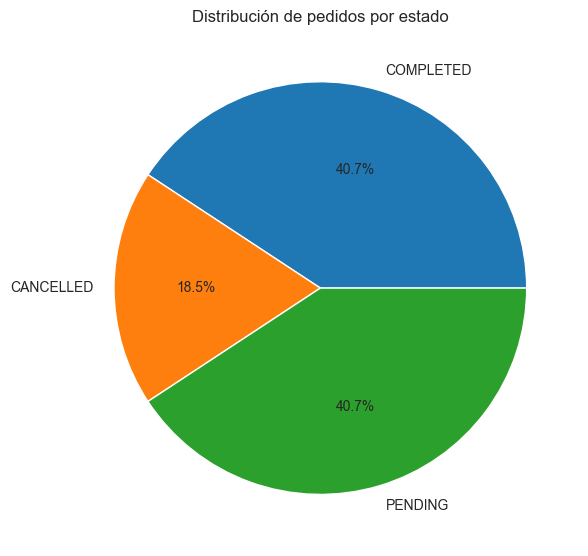

In [7]:
# % de pedidos por estado
df_status = con.execute("""
    SELECT status, COUNT(*) AS total
    FROM stage_orders
    GROUP BY status
""").df()

plt.figure(figsize=(6,6))
plt.pie(df_status["total"], labels=df_status["status"], autopct="%1.1f%%")
plt.title("Distribución de pedidos por estado")
plt.tight_layout()
plt.show()

**Distribución de pedidos por estado.** Este gráfico muestra qué porcentaje de los 
pedidos totales se encuentra en cada estado (completado, pendiente, cancelado). 
Un porcentaje alto de pedidos cancelados o pendientes podría señalar problemas en 
el proceso de fulfillment o pago, mientras que una alta proporción de pedidos 
completados refleja una operación de ventas saludable.

In [8]:
con.close()